# Three-Class Sentiment Analysis

This notebook classifies short social-media text as **negative**, **neutral**, or **positive**. It inspects the labeled dataset, applies reproducible text preprocessing, compares Multinomial Naive Bayes with Logistic Regression using TF-IDF, evaluates on a stratified 80/20 holdout, and inspects five errors.

**Dataset:** Cardiff NLP's [TweetEval sentiment](https://huggingface.co/datasets/cardiffnlp/tweet_eval) configuration. The included Parquet file is its labeled training split. Label IDs are `0 = negative`, `1 = neutral`, and `2 = positive`. The source card currently lists the license as unknown; consult the source terms before redistributing content or using a resulting model commercially.

The notebook uses a fixed random seed for a repeatable holdout split. It is a learning baseline, not a production-ready moderation or customer-support system.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "tweet_eval_sentiment_train.parquet"
LABEL_NAMES = {0: "negative", 1: "neutral", 2: "positive"}
CLASS_ORDER = ["negative", "neutral", "positive"]
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}. See README.md for source details.")
print(f"Project folder: {PROJECT_DIR}")
print(f"Dataset file: {DATA_PATH.name}")

Project folder: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA ANALYTICS\Level 1\Sentiment Analysis
Dataset file: tweet_eval_sentiment_train.parquet


## 1. Load and inspect the data

Each record contains a tweet and its human-assigned sentiment label. The original label IDs are mapped to readable names; no records are sampled or relabeled here. Check the shape, dtypes, nulls, duplicate texts, and class counts before modeling.

In [2]:
data = pd.read_parquet(DATA_PATH)
required_columns = {"text", "label"}
if not required_columns.issubset(data.columns):
    raise ValueError(f"Expected columns {required_columns}; found {set(data.columns)}")
data = data[["text", "label"]].copy()
data["label"] = pd.to_numeric(data["label"], errors="raise").astype("int64")
if not data["label"].isin(LABEL_NAMES).all():
    raise ValueError("The dataset contains an unmapped sentiment label")
data["sentiment"] = data["label"].map(LABEL_NAMES)

print("Shape:", data.shape)
print("\nDtypes:\n", data.dtypes.to_string())
print("\nMissing values:\n", data.isna().sum().to_string())
duplicate_rows = data.loc[data["text"].duplicated(keep=False)]
duplicate_label_counts = duplicate_rows.groupby("text")["label"].nunique()
print(f"\nRepeated text rows: {data['text'].duplicated().sum():,}")
print(f"Repeated text groups: {duplicate_rows['text'].nunique():,}")
print(f"Repeated text groups with conflicting labels: {(duplicate_label_counts > 1).sum():,}")
print("\nClass distribution:\n", data["sentiment"].value_counts().reindex(CLASS_ORDER).to_string())
display(data.head())

Shape: (45615, 3)

Dtypes:
 text           str
label        int64
sentiment      str

Missing values:
 text         0
label        0
sentiment    0

Repeated text rows: 29
Repeated text groups: 25
Repeated text groups with conflicting labels: 3

Class distribution:
 sentiment
negative     7093
neutral     20673
positive    17849


,text,label,sentiment
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


### Class distribution

The sentiment labels are not equally represented: neutral and positive examples are more common than negative examples in this training split. There are also a few repeated text groups, including groups with inconsistent labels. Those source annotations are preserved, but the eventual split groups identical cleaned text together to prevent duplicate-text leakage. Macro-averaged evaluation gives each sentiment class equal weight.

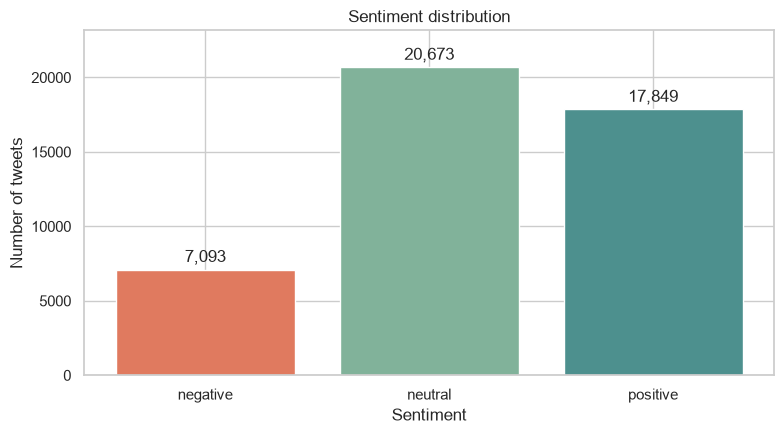

,percent
sentiment,
negative,15.55
neutral,45.32
positive,39.13


In [3]:
class_counts = data["sentiment"].value_counts().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(class_counts.index, class_counts.values, color=["#e07a5f", "#81b29a", "#4d908e"])
ax.set(title="Sentiment distribution", xlabel="Sentiment", ylabel="Number of tweets")
ax.bar_label(bars, labels=[f"{n:,}" for n in class_counts.values], padding=3)
ax.set_ylim(0, class_counts.max() * 1.12)
plt.tight_layout()
plt.show()
display((class_counts / len(data) * 100).round(2).rename("percent").to_frame())

## 2. Text preprocessing

The preprocessing function lowercases text, expands common negative contractions, removes URLs and `@user` mentions, strips punctuation/numbers, tokenizes alphabetic words with a regular expression, and removes common English stopwords. Negators (`no`, `nor`, `not`, `never`) are deliberately kept because they can reverse sentiment. Hashtag marker punctuation is removed while its word is retained. Stemming and lemmatization are not used so word forms remain readable in the class-specific WordClouds.

TF-IDF (**Term Frequency–Inverse Document Frequency**) converts tokens into numeric features: a term receives more weight when it is frequent in a particular tweet but less weight when it appears across many tweets. The vectorizer learns vocabulary and IDF weights from training text only, preventing test-set leakage.

In [4]:
negators = {"no", "nor", "not", "never"}
stop_words = set(ENGLISH_STOP_WORDS) - negators

def clean_text(text):
    """Normalize a tweet into alphabetic tokens while preserving negation."""
    text = str(text).lower()
    text = re.sub(r"\b(can't|cannot|won't|shan't)\b", lambda match: {
        "can't": "can not", "cannot": "can not", "won't": "will not", "shan't": "shall not"
    }[match.group(1)], text)
    text = re.sub(r"\b(\w+)n['’]t\b", r"\1 not", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    tokens = re.findall(r"[a-z]+", text)
    return " ".join(token for token in tokens if token not in stop_words and token != "user")

assert "not" in clean_text("I don't like this")
assert "not" in clean_text("This isn't good")
data["clean_text"] = data["text"].map(clean_text)
empty_after_cleaning = int(data["clean_text"].str.strip().eq("").sum())
print(f"Texts empty after preprocessing: {empty_after_cleaning:,} of {len(data):,}")
display(data[["text", "clean_text", "sentiment"]].head(8))

Texts empty after preprocessing: 0 of 45,615


,text,clean_text,sentiment
0,"""QT @user In the original draft of the 7th boo...",qt original draft th book remus lupin survived...,positive
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains lineup thur...,neutral
2,Sorry bout the stream last night I crashed out...,sorry bout stream night crashed tonight sure m...,neutral
3,Chase Headley's RBI double in the 8th inning o...,chase headley s rbi double th inning david pri...,neutral
4,@user Alciato: Bee will invest 150 million in ...,alciato bee invest million january summer plan...,positive
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,lit mum kerry louboutins wonder willam owns lo...,positive
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",soul train oct halloween special ft t dot fine...,positive
7,So disappointed in wwe summerslam! I want to s...,disappointed wwe summerslam want john cena win...,negative


## 3. WordClouds by sentiment

These class-specific WordClouds summarize frequent words after the same cleanup and stopword removal used for modeling. They are descriptive, not evidence that a particular word causes a sentiment label.

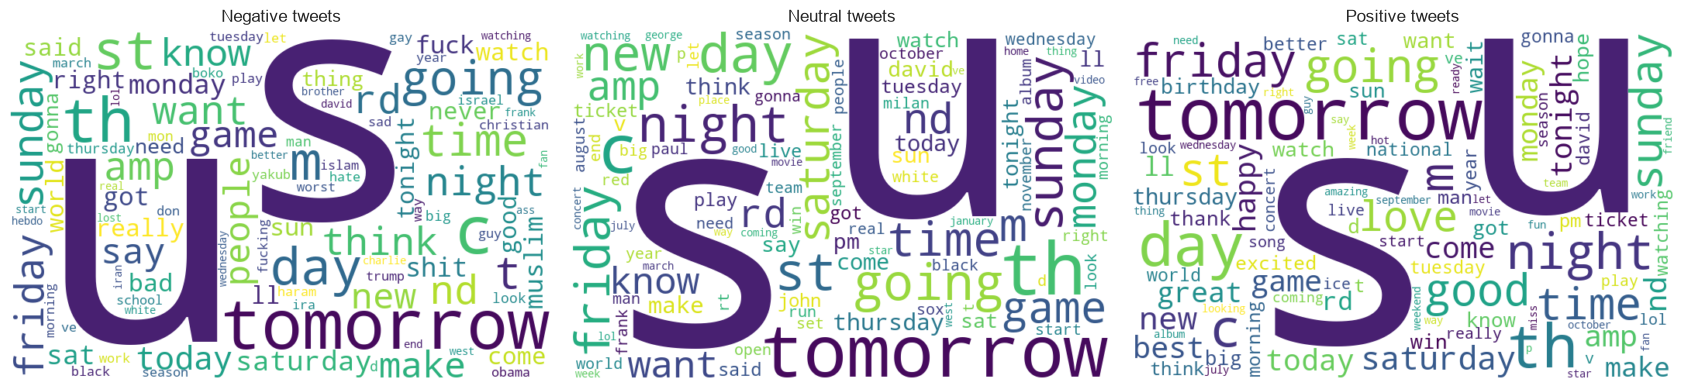

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, sentiment in zip(axes, CLASS_ORDER):
    corpus = " ".join(data.loc[data["sentiment"].eq(sentiment), "clean_text"])
    if not corpus.strip():
        raise ValueError(f"No usable tokens found for sentiment {sentiment!r}")
    cloud = WordCloud(width=700, height=450, background_color="white",
                      max_words=100, collocations=False, random_state=RANDOM_STATE)
    ax.imshow(cloud.generate(corpus), interpolation="bilinear")
    ax.set_title(f"{sentiment.title()} tweets")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Stratified 80/20 split and classifiers

A five-fold `StratifiedGroupKFold` split supplies one reproducible 80/20 fold: each unique cleaned text belongs to only one side, while class proportions remain very close. This prevents repeated text—including differently labeled copies—from leaking into both training and evaluation. Both models use the same TF-IDF settings and training rows: Multinomial Naive Bayes is a fast text-classification baseline, while Logistic Regression is a linear classifier that learns discriminative class weights.

In [6]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_indices, test_indices = next(splitter.split(
    data["clean_text"], data["sentiment"], groups=data["clean_text"]
))
X_train = data["clean_text"].iloc[train_indices]
X_test = data["clean_text"].iloc[test_indices]
y_train = data["sentiment"].iloc[train_indices]
y_test = data["sentiment"].iloc[test_indices]
assert set(X_train).isdisjoint(set(X_test)), "Repeated cleaned text leaked across the split"
print("Split: stratified group fold (one of five folds; 80/20)")
print(f"Training examples: {len(X_train):,} ({len(X_train) / len(data):.0%})")
print(f"Test examples: {len(X_test):,} ({len(X_test) / len(data):.0%})")
print("Training proportions:\n", y_train.value_counts(normalize=True).reindex(CLASS_ORDER).round(3).to_string())
print("Test proportions:\n", y_test.value_counts(normalize=True).reindex(CLASS_ORDER).round(3).to_string())

def make_model(classifier):
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                  min_df=2, max_df=0.98, sublinear_tf=True,
                                  dtype=np.float32)),
        ("classifier", classifier),
    ])

models = {
    "Multinomial Naive Bayes": make_model(MultinomialNB(alpha=0.5)),
    "Logistic Regression": make_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
}
predictions = {}
probabilities = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)
    print(f"Trained {name}")

Split: stratified group fold (one of five folds; 80/20)
Training examples: 36,492 (80%)
Test examples: 9,123 (20%)
Training proportions:
 sentiment
negative    0.155
neutral     0.453
positive    0.391
Test proportions:
 sentiment
negative    0.156
neutral     0.453
positive    0.391


Trained Multinomial Naive Bayes


Trained Logistic Regression


## 5. Model evaluation

Accuracy measures the overall fraction correct. Precision reflects how often a predicted class is correct; recall reflects how many actual examples of a class are found. Macro averages weight negative, neutral, and positive equally, while weighted averages account for support. The confusion matrices show which classes are most often confused.

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Logistic Regression,0.6569,0.6586,0.5920,0.6095,0.6597,0.6569,0.6490
Multinomial Naive Bayes,0.6068,0.6140,0.5142,0.5197,0.6102,0.6068,0.5859



Multinomial Naive Bayes — per-class report


,precision,recall,f1-score,support
negative,0.623,0.173,0.271,1419.000
neutral,0.586,0.712,0.643,4135.000
positive,0.633,0.658,0.645,3569.000
accuracy,0.607,0.607,0.607,0.607
macro avg,0.614,0.514,0.520,9123.000
weighted avg,0.610,0.607,0.586,9123.000



Logistic Regression — per-class report


,precision,recall,f1-score,support
negative,0.646,0.361,0.463,1419.000
neutral,0.630,0.760,0.689,4135.000
positive,0.699,0.655,0.676,3569.000
accuracy,0.657,0.657,0.657,0.657
macro avg,0.659,0.592,0.610,9123.000
weighted avg,0.660,0.657,0.649,9123.000


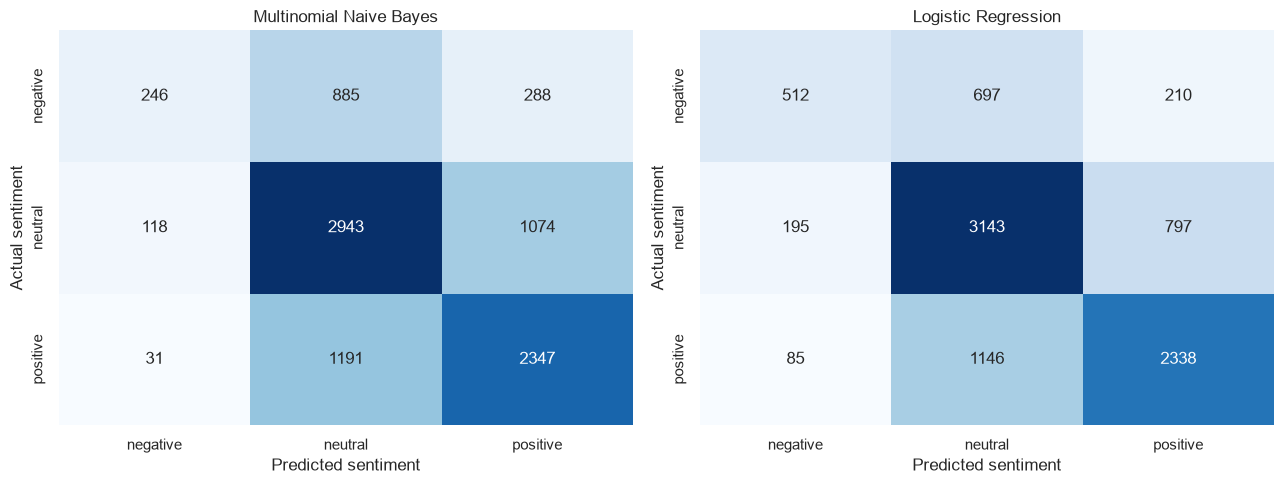

Best model by held-out macro F1: Logistic Regression (macro F1 = 0.610)


In [7]:
metric_rows = []
reports = {}
for name, y_pred in predictions.items():
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
    )
    metric_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    })
    reports[name] = classification_report(y_test, y_pred, labels=CLASS_ORDER,
                                           zero_division=0, output_dict=True)

metrics = pd.DataFrame(metric_rows).set_index("model").sort_values("f1_macro", ascending=False)
display(metrics.round(4))
for name in models:
    print(f"\n{name} — per-class report")
    display(pd.DataFrame(reports[name]).T.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set(title=name, xlabel="Predicted sentiment", ylabel="Actual sentiment")
plt.tight_layout()
plt.show()

best_model_name = metrics.index[0]
print(f"Best model by held-out macro F1: {best_model_name} "
      f"(macro F1 = {metrics.loc[best_model_name, 'f1_macro']:.3f})")

## 6. Error analysis: five held-out mistakes

The following five examples are misclassified by the model selected using macro F1. The lowest-confidence mistakes are shown first, where confidence is the highest predicted class probability. Short posts, implicit sentiment, slang, sarcasm, domain-specific references, and mixed emotional cues can make labels ambiguous; inspect the actual examples rather than treating these possibilities as proven causes.

In [8]:
best_predictions = predictions[best_model_name]
best_probabilities = probabilities[best_model_name]
confidence = best_probabilities.max(axis=1)
error_table = pd.DataFrame({
    "text": data.loc[X_test.index, "text"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": best_predictions,
    "confidence": confidence,
}, index=X_test.index)
errors = error_table.loc[error_table["actual"].ne(error_table["predicted"])].sort_values("confidence")
if errors.empty:
    raise RuntimeError("No test errors were available for the requested error analysis")
display(errors.head(5).reset_index(drop=True).style.format({"confidence": "{:.3f}"}))
print(f"Total {best_model_name} test errors: {len(errors):,} / {len(y_test):,}")

,text,actual,predicted,confidence
0,But some of ya need to calm down\u002c there just snippets! And besides we get to hear them on iTunes on Monday so it\u2019s not really a big deal!,neutral,negative,0.335
1,"""Omg, it probablY means not going into hiding, but hopefully HOPEFULLY OT9 made up and Jessica is getting a 2nd chance""",positive,neutral,0.342
2,Looks like our English kaki at tnp missed the person for that wonder pass for mata 1st goal Eden hazard !,neutral,negative,0.343
3,@user Nooooooooo rosanne! They\u2019ve just restocked them and me going overseas Sunday means I can\u2019t afford them :\u2019(,negative,neutral,0.344
4,"""Just got a large iced coffee from Dunkin, which is my 6th cup of coffee (so far) today. Do you think that's bad?""",positive,neutral,0.346


Total Logistic Regression test errors: 3,130 / 9,123


### What these errors suggest

The displayed errors include upbeat fandom language labeled neutral, a sports post whose word “missed” may have pulled the prediction negative, and a tweet with repeated “No” that has strong negative context but was predicted neutral. The coffee post is labeled positive despite its self-deprecating question, illustrating the subjectivity of annotation. These cases show how mixed cues, negation, domain context, and conversational tone challenge a bag-of-words model.

## 7. Conclusion and practical application

The held-out metrics above determine which classifier performed best on this split; macro F1 is the selection criterion because it treats all three sentiment classes equally. For a real-world starting point, a sentiment classifier can help summarize broad trends in product reviews, support tickets, or public feedback so analysts can prioritize themes for human review.

This dataset consists of short social posts and may not represent another domain, language, or time period. Neutral sentiment is especially context-dependent, and sarcasm, negation, emerging slang, and class imbalance can produce errors. Before deployment, validate on representative, current data, monitor per-class errors and drift, and keep a human in the loop for consequential decisions.